# UAS Pengolahan Citra Digital
* **Nama:** [ARIS MUNANDAR]
* **NIM:** [24146051]

Library berhasil diimpor!
Memuat dan memproses citra...
Total data citra yang dimuat: 4317
Bentuk data setelah dflatten: (4317, 3072)
Jumlah data training: 3453
Jumlah data testing: 864
Melatih model MLP (sedang berjalan)...
Iteration 1, loss = 1.58399275
Iteration 2, loss = 1.32934985
Iteration 3, loss = 1.26490037
Iteration 4, loss = 1.26664361
Iteration 5, loss = 1.20248966
Iteration 6, loss = 1.17694840
Iteration 7, loss = 1.15548231
Iteration 8, loss = 1.13811321
Iteration 9, loss = 1.11788126
Iteration 10, loss = 1.11621563
Iteration 11, loss = 1.09568011
Iteration 12, loss = 1.07687469
Iteration 13, loss = 1.05397862
Iteration 14, loss = 1.04185322
Iteration 15, loss = 1.03119584
Iteration 16, loss = 1.02455530
Iteration 17, loss = 1.01418430
Iteration 18, loss = 1.00030843
Iteration 19, loss = 0.99347321
Iteration 20, loss = 0.97762825
Iteration 21, loss = 0.95775590
Iteration 22, loss = 0.93679698
Iteration 23, loss = 0.94797148
Iteration 24, loss = 0.92744975
Iteration 25, lo

c:\Users\Hype GLK\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


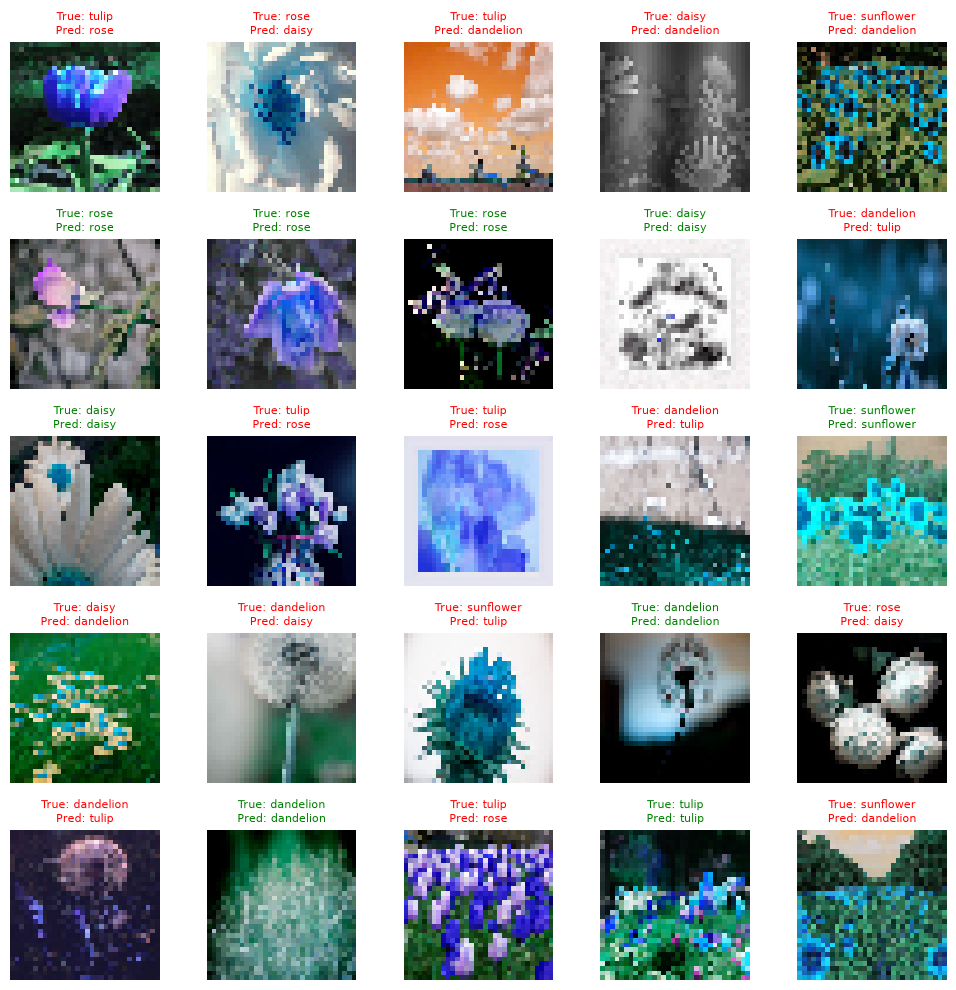

In [2]:
# ==========================================
# UAS PENGOLAHAN CITRA DIGITAL
# Nama: [Nama Lengkap Anda]
# NIM: [NIM Anda]
# ==========================================

# 1. IMPORT LIBRARY
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

print("Library berhasil diimpor!")

# 2. LOAD DATASET & PREPROCESSING
# Menggunakan folder saat ini (.) tempat folder kategori daisy, dandelion, dll berada
dataset_path = '.' 
categories = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
img_size = 32  # Diatur ke 32x32 agar proses loading & training cepat

data = []
labels = []

print("Memuat dan memproses citra...")
for category in categories:
    path = os.path.join(dataset_path, category)
    class_index = categories.index(category)
    
    if not os.path.exists(path):
        print(f"Peringatan: Folder {category} tidak ditemukan!")
        continue
        
    for img_name in os.listdir(path):
        try:
            img_path = os.path.join(path, img_name)
            img_arr = cv2.imread(img_path)
            
            if img_arr is not None:
                # Resize gambar agar seragam dan ringan diproses
                resized_img = cv2.resize(img_arr, (img_size, img_size))
                data.append(resized_img)
                labels.append(class_index)
        except Exception as e:
            pass

# Konversi ke numpy array
X = np.array(data)
y = np.array(labels)

# Normalisasi piksel citra ke rentang [0, 1] dan flatten citra untuk MLP
X = X / 255.0
X_flattened = X.reshape(X.shape[0], -1)

print(f"Total data citra yang dimuat: {X.shape[0]}")
print(f"Bentuk data setelah dflatten: {X_flattened.shape}")

# 3. PEMBAGIAN DATA TRAINING & TESTING (80% : 20%)
# Ganti angka di bawah ini dengan NIM Anda masing-masing[cite: 1]
NIM_RANDOM_STATE = 24146051 

X_train, X_test, y_train, y_test = train_test_split(
    X_flattened, 
    y, 
    test_size=0.2, 
    random_state=NIM_RANDOM_STATE
)

print(f"Jumlah data training: {X_train.shape[0]}")
print(f"Jumlah data testing: {X_test.shape[0]}")

# 4. PELATIHAN MODEL MULTI-LAYER PERCEPTRON (MLP)
mlp_model = MLPClassifier(
    hidden_layer_sizes=(50,), 
    activation='relu', 
    solver='adam', 
    max_iter=200, 
    random_state=NIM_RANDOM_STATE,
    verbose=True
)

print("Melatih model MLP (sedang berjalan)...")
mlp_model.fit(X_train, y_train)
print("Pelatihan selesai!")

# 5. EVALUASI MODEL
y_pred = mlp_model.predict(X_test)

# Menampilkan laporan klasifikasi dengan 4 digit di belakang koma[cite: 1]
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=categories, digits=4))

accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%")

# 6. VISUALISASI 5 GAMBAR ACAK DARI TIAP KELAS BESERTA PREDIKSINYA
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
axes = axes.flatten()

# Mengambil indeks secara acak untuk pengujian visualisasi
random_indices = random.sample(range(len(X_test)), min(25, len(X_test)))

for i, idx in enumerate(random_indices):
    img = X_test[idx].reshape(img_size, img_size, 3)
    true_label = categories[y_test[idx]]
    pred_label = categories[y_pred[idx]]
    
    axes[i].imshow(img)
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()